In [28]:
import os
import sys
import django

# Change to the Django project directory (where manage.py is)
project_root = '/Users/alifffayruz/Documents/UWE/25-26 Semester/DaESD/code/DESD-BRFN/DESD_BRFN'
os.chdir(project_root)
sys.path.insert(0, project_root)

# Set the settings module
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'BRFN.settings')

# Initialize Django
django.setup()

print("Django setup successful!")
print(f"Current directory: {os.getcwd()}")
print(f"Settings module: {os.environ['DJANGO_SETTINGS_MODULE']}")

Django setup successful!
Current directory: /Users/alifffayruz/Documents/UWE/25-26 Semester/DaESD/code/DESD-BRFN/DESD_BRFN
Settings module: BRFN.settings


In [29]:
from collections import defaultdict, Counter


import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from django.db.models import Window, F
from django.db.models.functions import RowNumber
from orders.models import OrderItem, OrderPayment
from products.models import Product
from django.db.models import Sum, Count, Avg

import datetime


In [30]:
def get_user_orders_with_products():
    '''
    quantity ignored.
    user_id : (order_num, datetime, products in order)
    1 : (664, datetime.datetime(2026, 3, 14, 10, 12, 53, 931192, tzinfo=datetime.timezone.utc), [42, 43, 140, 271, 52, 183, 184])]
    '''
    user_orders = defaultdict(list)

    # ascending order (oldest to newest)
    # order_items = OrderItem.objects.filter(
    #     producer_order__payment__payment_status='paid'
    # ).exclude(
    #     producer_order__payment__user__customer_profile__id=1
    # ).select_related(
    #     'product', 'producer_order__payment__user'
    # ).order_by('producer_order__payment__created_at')

    # descending order (newest to oldest)
    order_items = OrderItem.objects.filter(
        producer_order__payment__payment_status='paid'
    ).exclude(
        producer_order__payment__user__customer_profile__id=1
    ).select_related(
        'product', 'producer_order__payment__user'
    ).order_by('-producer_order__payment__created_at')


    # exclude top row of each user.
    # order_items = OrderItem.objects.filter(
    #     producer_order__payment__payment_status='paid'
    # ).exclude(
    #     producer_order__payment__user__customer_profile__id=1
    # ).annotate(
    #     rn=Window(
    #         expression=RowNumber(),
    #         partition_by=[F('producer_order__payment__user')],
    #         order_by=F('producer_order__payment__created_at').desc()
    #     )
    # ).filter(
    #     rn__gt=1  # Exclude the first row (latest) for each user
    # ).select_related(
    #     'product', 'producer_order__payment__user'
    # ).order_by('producer_order__payment__created_at')

    current_user = None
    current_order = None
    products_in_order = []

    for item in order_items:
        user = item.producer_order.payment.user
        order_id = item.producer_order.payment.id
        timestamp = item.producer_order.payment.created_at
        product_id = item.product.id

        if user is None:
            continue

        if current_user != user.id:
            current_user = user.id
            current_order = None
            products_in_order = []

        if current_order != order_id:
            if current_order is not None and products_in_order:
                user_orders[current_user].append((current_order, timestamp, list(set(products_in_order))))
            current_order = order_id
            products_in_order = [product_id]
        else:
            if product_id not in products_in_order:
                products_in_order.append(product_id)

    if current_user and current_order and products_in_order:
        user_orders[current_user].append((current_order, timestamp, products_in_order))

    return dict(user_orders)

In [31]:
def get_top_products(user_orders, top_k=100):
    product_counter = Counter()
    for orders in user_orders.values():
        for _, _, prods in orders:
            product_counter.update(prods)
    top_product_ids = [pid for pid, _ in product_counter.most_common(top_k)]
    return set(top_product_ids)

In [32]:
def avg_basket():
    # Get all paid orders with their total item count (across all producers)
    orders = OrderPayment.objects.filter(
        payment_status='paid'
    ).annotate(
        # Sum up quantities OR count unique product lines – you decide
        total_quantity=Sum('producer_orders__order_items__quantity'),
        unique_products=Count('producer_orders__order_items__product', distinct=True),
        item_lines=Count('producer_orders__order_items')  # each OrderItem row
    )
    
    # Average basket size based on quantity (total units)
    avg_quantity = orders.aggregate(avg=Avg('total_quantity'))['avg']
    print(f"Average total quantity per order: {avg_quantity:.2f} units")
    
    # Average unique products per order
    avg_unique = orders.aggregate(avg=Avg('unique_products'))['avg']
    print(f"Average unique products per order: {avg_unique:.2f} products")
    
    # Average OrderItem rows (each product once, regardless of quantity)
    avg_lines = orders.aggregate(avg=Avg('item_lines'))['avg']
    print(f"Average product lines (rows) per order: {avg_lines:.2f}")

In [33]:
# def extract_temporal_features(timestamp: datetime.datetime, reference_date=None):
#     """
#     Simplified temporal features focusing on recency.
#     """
#     if reference_date is None:
#         reference_date = datetime.datetime.now(tz=timestamp.tzinfo)
# 
#     # Days since reference date (recency) - this is the key feature
#     days_diff = (reference_date - timestamp).days
#     # Normalize to [0, 1] (cap at 60 days)
#     days_since = min(days_diff, 60) / 60.0
    
#     # Weekend flag
#     is_weekend = 1.0 if timestamp.weekday() >= 5 else 0.0
    
#     return [days_since, is_weekend]


In [34]:
def extract_temporal_features(timestamp: datetime.datetime):
    day_of_week = timestamp.weekday()
    day_sin = np.sin(2 * np.pi * day_of_week / 7.0)
    day_cos = np.cos(2 * np.pi * day_of_week / 7.0)
    month = timestamp.month
    month_sin = np.sin(2 * np.pi * month / 12.0)
    month_cos = np.cos(2 * np.pi * month / 12.0)
    is_weekend = 1.0 if day_of_week >= 5 else 0.0
    return [day_sin, day_cos, month_sin, month_cos, is_weekend]

In [35]:
def encode_products_limited(all_product_ids, top_product_set):
    """
    Maps product IDs that are in top_product_set to 1..N.
    All others (rare products) are mapped to a single "other" token to ruduce noise
    padding=0, other=1, then products start at 2.
    """
    # Create mapping for top products
    top_list = sorted(top_product_set)  # deterministic order
    product_to_idx = {pid: i+2 for i, pid in enumerate(top_list)}  # start at 2
    # Reserve 0 for padding, 1 for "other"
    product_to_idx[0] = 0  # padding
    # "other" token id = 1
    other_token = 1
    idx_to_product = {0: 0, other_token: None}  # None means other
    for pid, idx in product_to_idx.items():
        if pid != 0:
            idx_to_product[idx] = pid
    num_products = len(top_list) + 1  # +1 for "other" token (index 1)
    return product_to_idx, idx_to_product, num_products, other_token

In [36]:
def build_sequences_limited(user_orders, product_to_idx, other_token, max_seq_len=7):
    X_products = []
    X_time = []
    y_multi_hot = []
    user_ids = []
    num_classes = max(product_to_idx.values()) + 1  # includes padding and other

    for user_id, orders in user_orders.items():
        if len(orders) < 2:
            continue

        for i in range(len(orders) - 1):
            context_orders = orders[:i+1]
            target_order = orders[i+1]

            # Build context product sequence (flattened)
            context_products = []
            context_timestamps = []
            for (_, ts, prod_list) in context_orders:
                for p in prod_list:
                    context_products.append(p)
                    context_timestamps.append(ts)

            # Truncate/pad to max_seq_len
            if len(context_products) > max_seq_len:
                context_products = context_products[-max_seq_len:]
                context_timestamps = context_timestamps[-max_seq_len:]
            pad_len = max_seq_len - len(context_products)
            if pad_len > 0:
                context_products = [0] * pad_len + context_products
                zero_feat = [0.0] * 2
                context_timestamps = [zero_feat] * pad_len + context_timestamps

            # Encode products (map rare ones to other_token)
            encoded_prods = []
            for p in context_products:
                if p == 0:
                    encoded_prods.append(0)
                else:
                    encoded_prods.append(product_to_idx.get(p, other_token))

            # Time features
            time_feats = [extract_temporal_features(ts) if isinstance(ts, datetime.datetime) else ts
                          for ts in context_timestamps]

            # Multi-hot target for next order (only top products + other)
            target_vector = [0] * num_classes
            for target_pid in target_order[2]:
                idx = product_to_idx.get(target_pid, other_token)
                target_vector[idx] = 1

            X_products.append(encoded_prods)
            X_time.append(time_feats)
            y_multi_hot.append(target_vector)
            user_ids.append(user_id)

    return (np.array(X_products, dtype=np.int32),
            np.array(X_time, dtype=np.float32),
            np.array(y_multi_hot, dtype=np.float32),
            user_ids)

In [37]:
# def build_sequences_limited(user_orders, product_to_idx, other_token, max_seq_len=7):
#     X_products = []
#     X_time = []
#     y_multi_hot = []
#     user_ids = []
#     num_classes = max(product_to_idx.values()) + 1  # includes padding and other

#     for user_id, orders in user_orders.items():
#         if len(orders) < 2:
#             continue

#         for i in range(len(orders) - 1):
#             context_orders = orders[:i+1]
#             target_order = orders[i+1]

#             # Build context product sequence (flattened)
#             context_products = []
#             context_timestamps = []
#             for (_, ts, prod_list) in context_orders:
#                 for p in prod_list:
#                     context_products.append(p)
#                     context_timestamps.append(ts)

#             # Truncate/pad to max_seq_len
#             if len(context_products) > max_seq_len:
#                 context_products = context_products[-max_seq_len:]
#                 context_timestamps = context_timestamps[-max_seq_len:]
#             pad_len = max_seq_len - len(context_products)
#             if pad_len > 0:
#                 context_products = [0] * pad_len + context_products
#                 # Use the correct number of features (2 for days_since + is_weekend)
#                 zero_feat = [0.0] * 2  # Changed from 4 to 2 to match your extract_temporal_features
#                 context_timestamps = [zero_feat] * pad_len + context_timestamps

#             # Encode products (map rare ones to other_token)
#             encoded_prods = []
#             for p in context_products:
#                 if p == 0:
#                     encoded_prods.append(0)
#                 else:
#                     encoded_prods.append(product_to_idx.get(p, other_token))

#             # Extract time features - ensure we always get a list of features
#             time_feats = []
#             for ts in context_timestamps:
#                 if isinstance(ts, datetime.datetime):
#                     # It's a timestamp, extract features
#                     time_feats.append(extract_temporal_features(ts))
#                 elif isinstance(ts, list):
#                     # It's already a feature list, use it directly
#                     time_feats.append(ts)
#                 else:
#                     # Unknown type, use zeros
#                     time_feats.append([0.0] * 2)

#             # Multi-hot target for next order (only top products + other)
#             target_vector = [0] * num_classes
#             for target_pid in target_order[2]:
#                 idx = product_to_idx.get(target_pid, other_token)
#                 target_vector[idx] = 1

#             X_products.append(encoded_prods)
#             X_time.append(time_feats)
#             y_multi_hot.append(target_vector)
#             user_ids.append(user_id)

#     return (np.array(X_products, dtype=np.int32),
#             np.array(X_time, dtype=np.float32),
#             np.array(y_multi_hot, dtype=np.float32),
#             user_ids)

In [38]:
# ------------------------------------------------------------
#  Alternative: Keep "other" in inputs but exclude from outputs
# ------------------------------------------------------------
def build_sequences_limited_keep_other_in_input(user_orders, product_to_idx, other_token, max_seq_len=7):
    """
    Keep "other" token for INPUT sequences but exclude from TARGETS.
    This allows the model to see rare products in history but not predict them.
    """
    X_products = []
    X_time = []
    y_multi_hot = []
    user_ids = []
    
    # other_token should be 1 (as in your original)
    # Real products start at index 2
    num_classes = max(product_to_idx.values()) + 1
    real_product_start = 2  # First real product index

    for user_id, orders in user_orders.items():
        if len(orders) < 2:
            continue

        for i in range(len(orders) - 1):
            context_orders = orders[:i+1]
            target_order = orders[i+1]

            # Build context product sequence (flattened)
            context_products = []
            context_timestamps = []
            for (_, ts, prod_list) in context_orders:
                for p in prod_list:
                    context_products.append(p)
                    context_timestamps.append(ts)

            # Truncate/pad to max_seq_len
            if len(context_products) > max_seq_len:
                context_products = context_products[-max_seq_len:]
                context_timestamps = context_timestamps[-max_seq_len:]
            pad_len = max_seq_len - len(context_products)
            if pad_len > 0:
                context_products = [0] * pad_len + context_products
                zero_feat = [0.0] * 5
                context_timestamps = [zero_feat] * pad_len + context_timestamps

            # Encode products (rare ones -> other_token=1 for INPUT)
            encoded_prods = []
            for p in context_products:
                if p == 0:
                    encoded_prods.append(0)
                else:
                    encoded_prods.append(product_to_idx.get(p, other_token))

            # Time features
            time_feats = [extract_temporal_features(ts) if isinstance(ts, datetime.datetime) else ts
                          for ts in context_timestamps]

            # Multi-hot target - EXCLUDE "other" token (index 1)
            target_vector = [0] * num_classes
            valid_targets = False
            
            for target_pid in target_order[2]:
                idx = product_to_idx.get(target_pid, other_token)
                # Only include if it's a REAL product (idx >= real_product_start)
                if idx >= real_product_start:
                    target_vector[idx] = 1
                    valid_targets = True
                # Skip "other" token (idx == 1) entirely

            # Skip samples with no real product targets
            if not valid_targets:
                continue

            X_products.append(encoded_prods)
            X_time.append(time_feats)
            y_multi_hot.append(target_vector)
            user_ids.append(user_id)

    return (np.array(X_products, dtype=np.int32),
            np.array(X_time, dtype=np.float32),
            np.array(y_multi_hot, dtype=np.float32),
            user_ids)


In [39]:
def encode_users(user_ids):
    unique = sorted(set(user_ids))
    user_to_idx = {uid: i+1 for i, uid in enumerate(unique)}
    idx_to_user = {i+1: uid for i, uid in enumerate(unique)}
    user_to_idx[0] = 0
    idx_to_user[0] = 0
    return user_to_idx, idx_to_user, len(unique) + 1

In [40]:
def train_sigmoid_lstm(
    max_seq_len=5,
    batch_size=32,
    epochs=25,
    test_size=0.2,
    top_k_products=164, # half of db products
    save_model=True,
    model_save_path="ml/recommendation/final/sigmoid_lstm.keras",
    mappings_save_path="ml/recommendation/final/sigmoid_mappings.pkl"
):
    """
    Returns: (model, product_to_idx, idx_to_product, user_to_idx, idx_to_user, history)
    """
    print("=" * 60)
    print("Training sigmoid LSTM (multi-label, top-K products)")
    print("=" * 60)

    # 1. Load orders
    print("\n[1/6] Loading user orders...")
    user_orders = get_user_orders_with_products()
    if not user_orders:
        raise ValueError("No user orders found.")
    
    avg_basket()

    # 2. Limit to top K products
    print(f"\n[2/6] Selecting top {top_k_products} most frequent products...")
    top_products = get_top_products(user_orders, top_k=top_k_products)
    print(f"Selected {len(top_products)} products (plus 'other' token)")

    # 3. Encode products
    product_to_idx, idx_to_product, num_classes, other_token = encode_products_limited(
        [], (top_products)
    )
    print(f"Number of output classes (including 'other'): {num_classes}")

    # 4. Build sequences
    print("\n[3/6] Building sequences...")
    X_prod, X_time, y_multi, user_ids = build_sequences_limited_keep_other_in_input(
        user_orders, product_to_idx, other_token, max_seq_len
    )
    print(f"Total samples: {len(X_prod)}")
    print(f"Positive labels per sample: {np.sum(y_multi, axis=1).mean():.2f}")

    # 5. Encode users
    user_to_idx, idx_to_user, num_users = encode_users(user_ids)
    user_encoded = np.array([user_to_idx[uid] for uid in user_ids], dtype=np.int32).reshape(-1, 1)

    # 6. Train/val split
    print("\n[4/6] Splitting data...")
    indices = np.arange(len(X_prod))
    train_idx, val_idx = train_test_split(indices, test_size=test_size, random_state=42)

    X_prod_train = X_prod[train_idx]
    X_prod_val   = X_prod[val_idx]
    X_time_train = X_time[train_idx]
    X_time_val   = X_time[val_idx]
    y_train = y_multi[train_idx]
    y_val   = y_multi[val_idx]
    user_train = user_encoded[train_idx]
    user_val   = user_encoded[val_idx]

    # Compute class weights to balance positive/negative
    # For multi-label, we can use simple pos_weight per class or global pos_weight.
    # Here we compute a global positive weight (neg/pos ratio)
    pos_count = np.sum(y_train)
    neg_count = y_train.size - pos_count
    pos_weight = neg_count / max(pos_count, 1)
    print(f"Positive weight: {pos_weight:.2f}")

    # 7. Build model
    print("\n[5/6] Building LSTM model...")
    product_input = keras.Input(shape=(max_seq_len,), name='product_input')
    time_input = keras.Input(shape=(max_seq_len, 5), name='time_input')
    user_input = keras.Input(shape=(1,), name='user_input')

    prod_embed = keras.layers.Embedding(
        input_dim=num_classes + 1,  # +1 because indices go up to num_classes (including other)
        output_dim=64,
        mask_zero=True,
        name='prod_emb'
    )(product_input)

    combined = keras.layers.Concatenate(axis=-1)([prod_embed, time_input])

    # may consider stack lstm tho requires more time during training. 
    # results are similar therefore, i decided to just stick with 1 lstm + attention layer. 
    lstm_out = keras.layers.LSTM(64, dropout=0.2, return_sequences=True, name='lstm')(combined)
    # lstm_out = keras.layers.LSTM(32, dropout=0.3, return_sequences=True, name='lstm1')(lstm_out)

    attention = keras.layers.MultiHeadAttention(num_heads=4, key_dim=32, name='attention')(lstm_out, lstm_out)
    # attention_pooled = keras.layers.GlobalAveragePooling1D()(attention)

    recency_weights = tf.constant([0.1, 0.15, 0.2, 0.25, 0.3], dtype=tf.float32)
    weighted_attention = attention * recency_weights[tf.newaxis, :, tf.newaxis]
    attention_pooled = keras.layers.GlobalAveragePooling1D()(weighted_attention)

    user_embed = keras.layers.Embedding(input_dim=num_users, output_dim=16, name='user_emb')(user_input)
    user_flat = keras.layers.Flatten()(user_embed)
    # user_flat = keras.layers.Dropout(0.8)(user_flat)

    # if not using attention layer, uncomment the other option
    merged = keras.layers.Concatenate()([attention_pooled, user_flat])
    # merged = keras.layers.Concatenate()([lstm_out, user_flat])

    dense = keras.layers.Dense(32, activation='relu')(merged)
    # dense = keras.layers.BatchNormalization()(dense) # DONT USE BATCH NORMALIZATION ( it will make all predictions generic/universal)
    dropout = keras.layers.Dropout(0.1)(dense)

    # Sigmoid output for multi-label
    output_size = max(product_to_idx.values()) + 1
    output = keras.layers.Dense(output_size, activation='sigmoid', name='output')(dropout)

    model = keras.Model(inputs=[product_input, time_input, user_input], outputs=output)

    # Use binary crossentropy with class weight (apply via sample weights or inside loss)
    # We'll add a custom loss that applies pos_weight
    
    model.compile(
        optimizer='adam',
        # loss=focal_loss(),
        # loss='binary_crossentropy',
        loss=tf.keras.losses.BinaryFocalCrossentropy(),
        metrics=['binary_accuracy', tf.keras.metrics.Precision(top_k=5), tf.keras.metrics.Recall(top_k=5)]
    )
    model.summary()
    

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1),
        keras.callbacks.ModelCheckpoint('ml/recommendation/final/checkpoint/sigmoid_checkpoint.keras', monitor='val_loss', save_best_only=True)
    ]

    # 8. Train
    print("\n[6/6] Training...")
    history = model.fit(
        [X_prod_train, X_time_train, user_train],
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=([X_prod_val, X_time_val, user_val], y_val),
        callbacks=callbacks,
        verbose=1,
    )

    # Evaluate
    val_loss, val_bin_acc, val_prec, val_rec= model.evaluate([X_prod_val, X_time_val, user_val], y_val, verbose=0)
    print(f"\nValidation: loss={val_loss:.4f}, binary_accuracy={val_bin_acc:.4f}, precision={val_prec:.4f}, recall={val_rec:.4f}")

    # -------------
    # Multi-label ranking metrics
    from sklearn.metrics import average_precision_score, label_ranking_average_precision_score

    y_pred_proba = model.predict([X_prod_val, X_time_val, user_val], verbose=0)
    # 1. Mean Average Precision (per-class)
    ap_list = []
    for i in range(y_val.shape[1]):
        if len(np.unique(y_val[:, i])) > 1:
            ap_list.append(average_precision_score(y_val[:, i], y_pred_proba[:, i]))
    map_score = np.mean(ap_list) if ap_list else 0.0

    # 2. Label Ranking Average Precision
    lrap_score = label_ranking_average_precision_score(y_val, y_pred_proba)
    print(f"Mean AP (per-class): {map_score:.4f}")
    print(f"Label Ranking AP: {lrap_score:.4f}")
    # ------------


    # Save
    if save_model:
        print(f"Saving model to {model_save_path}")
        model.save(model_save_path)
        mappings = {
            'product_to_idx': product_to_idx,
            'idx_to_product': idx_to_product,
            'user_to_idx': user_to_idx,
            'idx_to_user': idx_to_user,
            'max_seq_len': max_seq_len,
            'num_products': num_classes,
            'num_users': num_users,
            'other_token': other_token,
            'top_k_products': top_k_products
        }
        with open(mappings_save_path, 'wb') as f:
            pickle.dump(mappings, f)
        print("Mappings saved.")

    return model, X_prod_val, X_time_val, user_val, y_val, max_seq_len, product_to_idx, idx_to_product, user_to_idx, idx_to_user

    return model, product_to_idx, idx_to_product, user_to_idx, idx_to_user, history


In [41]:
import os
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"

import sys
import django
from unittest.mock import MagicMock

try:
    import cv2
except ImportError:
    sys.modules['cv2'] = MagicMock()

project_root = '/Users/alifffayruz/Documents/UWE/25-26 Semester/DaESD/code/DESD-BRFN/DESD_BRFN'
os.chdir(project_root)
sys.path.insert(0, project_root)
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'BRFN.settings')

from django.conf import settings

if not django.apps.apps.ready:
    django.setup()

if hasattr(settings, 'DATABASES'):
    if settings.DATABASES['default']['HOST'] == 'db':
        settings.DATABASES['default']['HOST'] = 'localhost'
        print("✓ Database host changed from 'db' to 'localhost'")

print("✓ Django setup complete")

✓ Django setup complete


In [42]:
product_count = Product.objects.all().count()
print(f"Total products: {product_count}")

active_count = Product.objects.filter(is_active=True).count()
print(f"Active products: {active_count}")

OperationalError: server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.


In [ ]:
# best:
#  max_seq_len=5,
# batch_size=32,
# epochs=25,
# test_size=0.2,
# top_k_products=164, # half of db products
# save_model=True,
# model_save_path="ml/recommendation/final/sigmoid_lstm.keras",
# mappings_save_path="ml/recommendation/final/sigmoid_mappings.pkl"

MAX_SEQ=5
BATCH_SIZE=32
EPOCHS=25
TEST_SIZE=0.2
TOP_K_PRODUCTS=168 # half of db products
SAVE_MODEL=True
MODEL_SAVE_PATH="ml/recommendation/final/sigmoid_lstm.keras"
MAPPING_SAVE_PATH="ml/recommendation/final/sigmoid_mappings.pkl"

# model, product_to_idx, idx_to_product, user_to_idx, idx_to_user, history = train_sigmoid_lstm(
#     max_seq_len=MAX_SEQ,
#     batch_size=BATCH_SIZE,
#     epochs=EPOCHS,
#     test_size=TEST_SIZE,
#     top_k_products=TOP_K_PRODUCTS,
#     save_model=SAVE_MODEL,
#     model_save_path=MODEL_SAVE_PATH,
#     mappings_save_path=MAPPING_SAVE_PATH,
# )

model, X_prod_val, X_time_val, user_val, y_val, max_seq_len, product_to_idx, idx_to_product, user_to_idx, idx_to_user = train_sigmoid_lstm(
    max_seq_len=MAX_SEQ,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    test_size=TEST_SIZE,
    top_k_products=TOP_K_PRODUCTS,
    save_model=SAVE_MODEL,
    model_save_path=MODEL_SAVE_PATH,
    mappings_save_path=MAPPING_SAVE_PATH,
)

Training sigmoid LSTM (multi-label, top-K products)

[1/6] Loading user orders...
Average total quantity per order: 8.75 units
Average unique products per order: 3.34 products
Average product lines (rows) per order: 3.34

[2/6] Selecting top 168 most frequent products...
Selected 168 products (plus 'other' token)
Number of output classes (including 'other'): 169

[3/6] Building sequences...
Total samples: 12353
Positive labels per sample: 2.32

[4/6] Splitting data...
Positive weight: 72.30

[5/6] Building LSTM model...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ product_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prod_emb            │ (None, 5, 64)     │     10,880 │ product_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 5)         │          0 │ product_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_input          │ (None, 5, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dims_1       │ (None, 5, 1)      │          0 │ not_equal_1[0][0] │
│ (ExpandDims)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zeros_like_1        │ (None, 5, 64)     │          0 │ prod_emb[0][0]    │
│ (ZerosLike)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 5, 64)     │          0 │ expand_dims_1[0]… │
│ (LogicalOr)         │                   │            │ zeros_like_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ones_like_1         │ (None, 5, 5)      │          0 │ time_input[0][0]  │
│ (OnesLike)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 5, 69)     │          0 │ logical_or_1[0][… │
│ (Concatenate)       │                   │            │ ones_like_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 5, 69)     │          0 │ prod_emb[0][0],   │
│ (Concatenate)       │                   │            │ time_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 5)         │          0 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 5, 64)     │     34,304 │ concatenate_1[0]… │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 5, 64)     │     33,216 │ lstm[0][0],       │
│ (MultiHeadAttentio… │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 5, 64)     │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_emb            │ (None, 1, 16)     │      1,600 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 88,202 (344.54 KB)

 Trainable params: 88,202 (344.54 KB)

 Non-trainable params: 0 (0.00 B)


[6/6] Training...
Epoch 1/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.9728 - loss: 0.0376 - precision: 0.0164 - recall: 0.0353 - val_binary_accuracy: 0.9864 - val_loss: 0.0220 - val_precision: 0.0181 - val_recall: 0.0392 - learning_rate: 0.0010
Epoch 2/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9864 - loss: 0.0227 - precision: 0.0173 - recall: 0.0374 - val_binary_accuracy: 0.9864 - val_loss: 0.0220 - val_precision: 0.0216 - val_recall: 0.0467 - learning_rate: 0.0010
Epoch 3/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9864 - loss: 0.0225 - precision: 0.0189 - recall: 0.0407 - val_binary_accuracy: 0.9864 - val_loss: 0.0218 - val_precision: 0.0230 - val_recall: 0.0497 - learning_rate: 0.0010
Epoch 4/25
309/309 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9864 - loss: 0.0223 - precision: 0.0206 - recall: 0.0443 - val_binary_accuracy: 0.9864 - val_loss: 0.0218 - val_precision: 0.0265 - val_recall: 0.0572 - learning_ra

# DEEPEXPLAINER

In [ ]:
n_background = min(100, len(X_prod_val))
background_indices = np.random.choice(len(X_prod_val), n_background, replace=False)

background_data = [
    X_prod_val[background_indices],  # product sequence input
    X_time_val[background_indices],  # time features input
    user_val[background_indices]     # user ID input
]

In [ ]:
print("Creating GradientExplainer...")
explainer = shap.GradientExplainer(model, background_data)


Creating GradientExplainer...


In [ ]:
n_test_samples = 5
test_indices = np.random.choice(len(X_prod_val), n_test_samples, replace=False)

X_test = [
    X_prod_val[test_indices],
    X_time_val[test_indices],
    user_val[test_indices]
]

## Permutation explainer



In [ ]:
import shap
import numpy as np
import tensorflow as tf

print("\n[1/2] Using PermutationExplainer...")

# Get the actual dimensions from your model
MAX_SEQ = max_seq_len  # from your training function
TIME_FEATURES = 5  # Your time features have 5 dimensions (hour, day_of_week, etc.)

def flatten_inputs(prod_data, time_data, user_data):
    """Flatten all inputs for SHAP"""
    n = len(prod_data)
    prod_flat = prod_data.reshape(n, -1)  # Shape: (n, MAX_SEQ)
    time_flat = time_data.reshape(n, -1)  # Shape: (n, MAX_SEQ * TIME_FEATURES)
    user_flat = user_data.reshape(n, -1)  # Shape: (n, 1)
    return np.hstack([prod_flat, time_flat, user_flat])

def predict_fn(x):
    """
    Prediction function that takes flattened input and reshapes for model.
    x shape: (batch_size, MAX_SEQ + MAX_SEQ*TIME_FEATURES + 1)
    """
    n = x.shape[0]
    
    # Calculate dimensions
    prod_dim = MAX_SEQ
    time_dim = MAX_SEQ * TIME_FEATURES
    user_dim = 1
    
    # Extract components
    prod_data = x[:, :prod_dim].astype(np.int32)
    time_data = x[:, prod_dim:prod_dim+time_dim].reshape(n, MAX_SEQ, TIME_FEATURES)
    user_data = x[:, prod_dim+time_dim:prod_dim+time_dim+user_dim].astype(np.int32)
    
    # Make predictions
    predictions = model.predict([prod_data, time_data, user_data], verbose=0)
    return predictions


[1/2] Using PermutationExplainer...


In [ ]:
# Prepare data (use validation data from training)
n_samples = min(500, len(X_prod_val))  # Limit to 500 samples for speed
X_prod_sample = X_prod_val[:n_samples]
X_time_sample = X_time_val[:n_samples]
user_sample = user_val[:n_samples]

# Flatten the data
X_combined = flatten_inputs(X_prod_sample, X_time_sample, user_sample)
print(f"Combined input shape: {X_combined.shape}")
print(f"Expected flattened size: {MAX_SEQ + MAX_SEQ*TIME_FEATURES + 1}")
print(f"Actual flattened size: {X_combined.shape[1]}")

Combined input shape: (500, 31)
Expected flattened size: 31
Actual flattened size: 31


In [ ]:
# Use a small background dataset
background_size = min(20, n_samples)
background = X_combined[:background_size]

# Create PermutationExplainer
print("Creating PermutationExplainer")
explainer = shap.PermutationExplainer(predict_fn, background, 
                                     max_evals=100)  # Reduce evaluations for speed

# Explain a few samples
test_size = min(10, n_samples)  # Keep small for PermutationExplainer
X_test = X_combined[:test_size]

print(f"Computing SHAP values for {test_size} samples")
shap_values = explainer.shap_values(X_test)

Creating PermutationExplainer...
Computing SHAP values for 10 samples (may take several minutes)...


In [ ]:
def visualize_shap_for_top_products(shap_values, X_test, model, X_prod_val, X_time_val, user_val, 
                                   idx_to_product, top_k=5):
    """
    Visualize SHAP values for the top K predicted products.
    """
    # Get predictions for test samples
    test_indices = np.arange(len(X_test))
    
    # Reconstruct the original test data from flattened X_test
    # This depends on how you flattened - adjust accordingly
    n_test = len(X_test)
    prod_dim = MAX_SEQ
    time_dim = MAX_SEQ * TIME_FEATURES
    
    test_prod = X_test[:, :prod_dim].astype(np.int32)
    test_time = X_test[:, prod_dim:prod_dim+time_dim].reshape(n_test, MAX_SEQ, TIME_FEATURES)
    test_user = X_test[:, prod_dim+time_dim:].astype(np.int32)
    
    # Get predictions
    predictions = model.predict([test_prod, test_time, test_user], verbose=0)
    
    # For each test sample, find top predicted products
    for sample_idx in range(min(3, n_test)):  # Show first 3 samples
        print(f"\n{'='*60}")
        print(f"Sample {sample_idx}")
        print(f"Product sequence: {test_prod[sample_idx]}")
        
        # Get top predicted products
        top_pred_indices = np.argsort(predictions[sample_idx])[-top_k:][::-1]
        
        print(f"\nTop {top_k} predicted products:")
        for rank, prod_idx in enumerate(top_pred_indices, 1):
            prod_name = idx_to_product.get(prod_idx, f"Product_{prod_idx}")
            print(f"  {rank}. {prod_name} (score: {predictions[sample_idx][prod_idx]:.4f})")
        
        # Visualize SHAP for the top product
        top_product = top_pred_indices[0]
        if isinstance(shap_values, list) and top_product < len(shap_values):
            sv_top = shap_values[top_product]
            
            if len(sv_top.shape) == 2:
                # Get SHAP values for this sample
                sv_sample = sv_top[sample_idx]
                
                # Create feature names (product positions)
                feature_names = [f"pos_{i}" for i in range(MAX_SEQ)]
                
                # Plot
                plt.figure(figsize=(10, 4))
                plt.bar(range(len(sv_sample)), sv_sample)
                plt.xlabel('Feature Index')
                plt.ylabel('SHAP Value')
                plt.title(f'SHAP Values for Product {prod_name} (Sample {sample_idx})')
                plt.xticks(range(len(sv_sample)), feature_names, rotation=45)
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
                # Show which products are at each position
                print("\nProduct sequence details:")
                for pos in range(MAX_SEQ):
                    if test_prod[sample_idx, pos] != 0:
                        prod_at_pos = idx_to_product.get(test_prod[sample_idx, pos], "Unknown")
                        print(f"  Position {pos}: {prod_at_pos} (importance: {sv_sample[pos]:.4f})")

# Use this function
visualize_shap_for_top_products(shap_values, X_test, model, X_prod_val, X_time_val, user_val, 
                                idx_to_product, top_k=5)


Sample 0
Product sequence: [149  57   1   1 138]

Top 5 predicted products:
  1. 92 (score: 0.2900)
  2. 108 (score: 0.2893)
  3. 191 (score: 0.2824)
  4. 250 (score: 0.2779)
  5. 110 (score: 0.2657)

Sample 1
Product sequence: [  1  74 107   1 156]

Top 5 predicted products:
  1. 122 (score: 0.2967)
  2. 315 (score: 0.2662)
  3. 204 (score: 0.2581)
  4. 322 (score: 0.2549)
  5. 201 (score: 0.2492)

Sample 2
Product sequence: [64  1 67  1 67]

Top 5 predicted products:
  1. 301 (score: 0.2427)
  2. 134 (score: 0.2386)
  3. 288 (score: 0.2309)
  4. 120 (score: 0.2297)
  5. 171 (score: 0.2280)


SHAP ANALYSIS FOR RECOMMENDATION MODEL

Using 200 validation samples for analysis...

[1/4] Calculating permutation importance...
  Baseline AP: 0.1101
  Testing product positions...
    Position 0: drop = -0.0017
    Position 4: drop = 0.0015
  Testing time features...

Expected feature counts:
  Product features: 5
  Time features: 25
  Total: 30
  Actual importances length: 30
Feature names length: 30


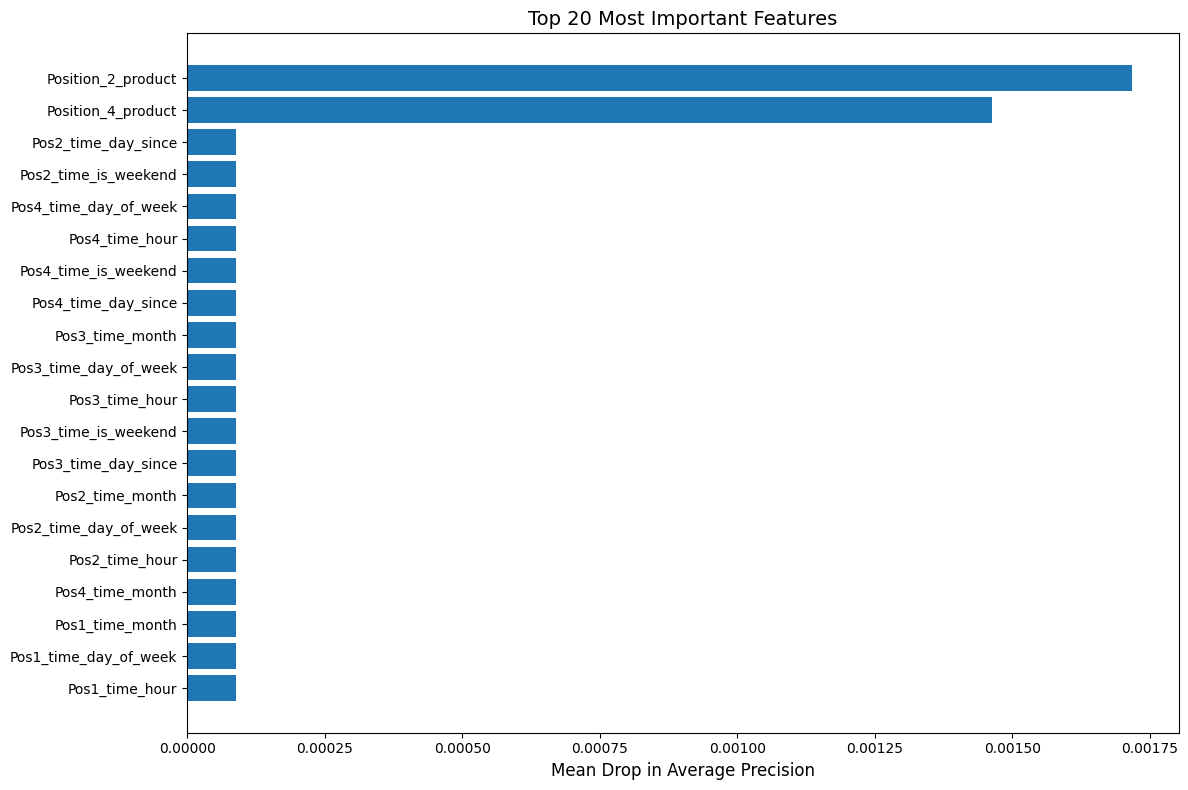


Top 10 features:
              feature  importance
   Position_2_product    0.001717
   Position_4_product    0.001464
  Pos2_time_day_since    0.000089
 Pos2_time_is_weekend    0.000089
Pos4_time_day_of_week    0.000089
       Pos4_time_hour    0.000089
 Pos4_time_is_weekend    0.000089
  Pos4_time_day_since    0.000089
      Pos3_time_month    0.000089
Pos3_time_day_of_week    0.000089

[2/4] Calculating feature group importance...
  Baseline AP: 0.1101
  Shuffling product sequence...
    Drop: -0.0038
  Shuffling time features...
    Drop: 0.0005
  Shuffling user IDs...
    Drop: 0.0774


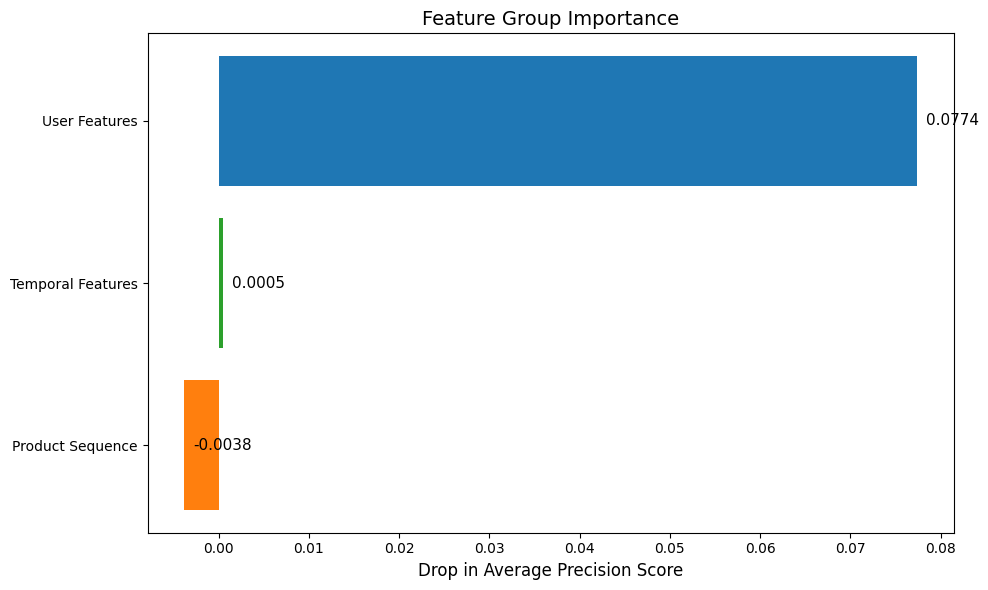


[3/4] Calculating position importance...
  Position 0: drop = 0.0056
  Position 1: drop = -0.0057
  Position 2: drop = -0.0026
  Position 3: drop = -0.0035
  Position 4: drop = 0.0046


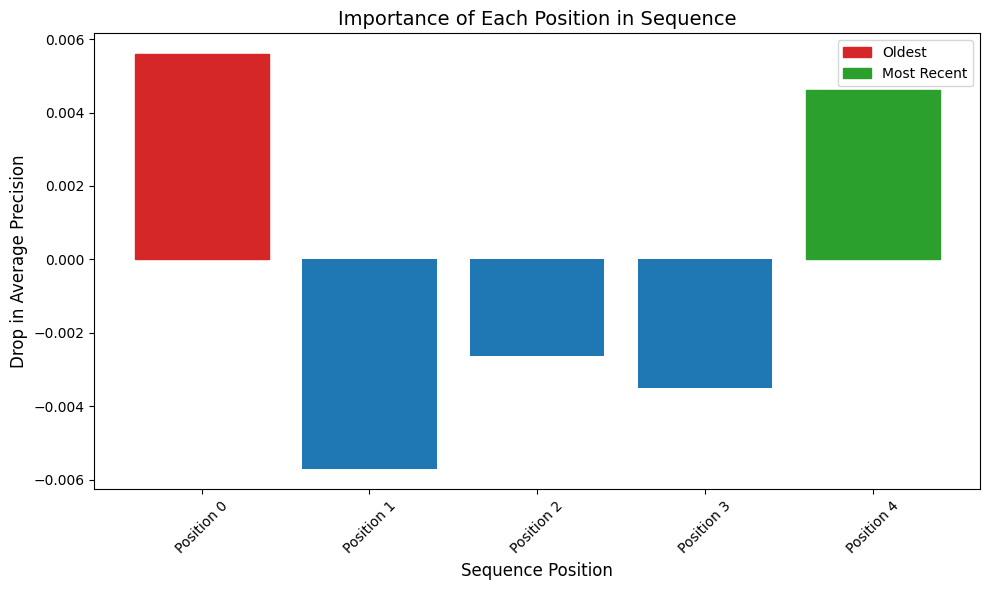


[4/4] Analyzing sample predictions...

--- Sample 0 ---
Product sequence (encoded): [149  57   1   1 138]
Top 5 predicted product indices: [ 25  41  97 124  43]
Actual product indices: [4]
Hits in top 3: None

--- Sample 5 ---
Product sequence (encoded): [124  88 144   1   1]
Top 5 predicted product indices: [ 66 153 144 131 139]
Actual product indices: [ 24  85 147]
Hits in top 3: None

--- Sample 10 ---
Product sequence (encoded): [ 10  39  46 108  56]
Top 5 predicted product indices: [28 61 16 62 46]
Actual product indices: [ 22  38  59 121]
Hits in top 3: None

--- Sample 20 ---
Product sequence (encoded): [  1 158  97  13   1]
Top 5 predicted product indices: [105  61  14  44  46]
Actual product indices: [ 13  14  56 105 154 166]
Hits in top 3: {np.int64(105), np.int64(14)}

--- Sample 50 ---
Product sequence (encoded): [102 142  86   1   1]
Top 5 predicted product indices: [  8 142  71  74  38]
Actual product indices: [103]
Hits in top 3: None

SHAP ANALYSIS SUMMARY

KEY INSIGHT

In [ ]:
# Cell: SHAP Analysis - Fixed Version
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("SHAP ANALYSIS FOR RECOMMENDATION MODEL")
print("="*60)

# Use subset for faster computation
n_samples = min(200, len(X_prod_val))
print(f"\nUsing {n_samples} validation samples for analysis...")

# Random sample for faster computation
np.random.seed(42)
sample_idx = np.random.choice(len(X_prod_val), n_samples, replace=False)
X_prod_sample = X_prod_val[sample_idx]
X_time_sample = X_time_val[sample_idx]
user_sample = user_val[sample_idx]
y_sample = y_val[sample_idx]

# -----------------------------------------------------------------
# METHOD 1: Custom Permutation Importance (No sklearn dependency)
# -----------------------------------------------------------------
print("\n[1/4] Calculating permutation importance...")

def custom_permutation_importance(model, X_prod, X_time, user, y_true, n_repeats=2):
    """Custom permutation importance for Keras models"""
    
    # Baseline score
    baseline = average_precision_score(y_true, model.predict([X_prod, X_time, user], verbose=0))
    print(f"  Baseline AP: {baseline:.4f}")
    
    # Get number of features
    n_prod_features = X_prod.shape[1]  # max_seq_len
    n_time_features = X_time.shape[1] * X_time.shape[2]  # max_seq_len * 5
    total_features = n_prod_features + n_time_features
    
    importances = np.zeros(total_features)
    
    # Test product positions (shuffle one position at a time)
    print("  Testing product positions...")
    for pos in range(n_prod_features):
        scores = []
        for _ in range(n_repeats):
            X_prod_shuffled = X_prod.copy()
            # Shuffle this position
            pos_col = X_prod_shuffled[:, pos].copy()
            np.random.shuffle(pos_col)
            X_prod_shuffled[:, pos] = pos_col
            
            score = average_precision_score(
                y_true,
                model.predict([X_prod_shuffled, X_time, user], verbose=0)
            )
            scores.append(baseline - score)
        importances[pos] = np.mean(scores)
        if pos == 0 or pos == n_prod_features - 1:
            print(f"    Position {pos}: drop = {importances[pos]:.4f}")
    
    # Test time features (shuffle all time features at once for simplicity)
    print("  Testing time features...")
    scores = []
    for _ in range(n_repeats):
        X_time_shuffled = X_time.copy()
        # Flatten and shuffle all time features
        flat_time = X_time_shuffled.reshape(len(X_time_shuffled), -1)
        for i in range(len(flat_time)):
            np.random.shuffle(flat_time[i])
        X_time_shuffled = flat_time.reshape(X_time.shape)
        
        score = average_precision_score(
            y_true,
            model.predict([X_prod, X_time_shuffled, user], verbose=0)
        )
        scores.append(baseline - score)
    
    # Distribute time importance across all time features
    time_importance = np.mean(scores)
    for i in range(n_prod_features, total_features):
        importances[i] = time_importance / n_time_features
    
    return importances

# Calculate permutation importance
importances = custom_permutation_importance(
    model, X_prod_sample, X_time_sample, user_sample, y_sample, n_repeats=2
)

# Create feature names (FIXED: Match lengths)
n_prod_features = MAX_SEQ
n_time_features = MAX_SEQ * 5  # 5 time features per position
total_features = n_prod_features + n_time_features

print(f"\nExpected feature counts:")
print(f"  Product features: {n_prod_features}")
print(f"  Time features: {n_time_features}")
print(f"  Total: {total_features}")
print(f"  Actual importances length: {len(importances)}")

feature_names = []

# Add product position features
for i in range(MAX_SEQ):
    feature_names.append(f'Position_{i}_product')

# Add time features for each position
time_feature_names = ['day_since', 'is_weekend', 'hour', 'day_of_week', 'month']  # 5 features
for i in range(MAX_SEQ):
    for j, name in enumerate(time_feature_names):
        feature_names.append(f'Pos{i}_time_{name}')

# Verify lengths match
print(f"Feature names length: {len(feature_names)}")
assert len(feature_names) == len(importances), f"Length mismatch: {len(feature_names)} vs {len(importances)}"

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Mean Drop in Average Precision', fontsize=12)
plt.title('Top 20 Most Important Features', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance_df.head(10).to_string(index=False))

# -----------------------------------------------------------------
# METHOD 2: Feature Group Importance
# -----------------------------------------------------------------
print("\n[2/4] Calculating feature group importance...")

def calculate_group_importance(model, X_prod, X_time, user, y_true):
    """Calculate importance for each feature group"""
    
    # Baseline score
    baseline = average_precision_score(
        y_true, 
        model.predict([X_prod, X_time, user], verbose=0)
    )
    print(f"  Baseline AP: {baseline:.4f}")
    
    importance = {}
    
    # 1. Product sequence importance
    print("  Shuffling product sequence...")
    X_prod_shuffled = X_prod.copy()
    for i in range(len(X_prod_shuffled)):
        np.random.shuffle(X_prod_shuffled[i])
    score = average_precision_score(
        y_true,
        model.predict([X_prod_shuffled, X_time, user], verbose=0)
    )
    importance['Product Sequence'] = baseline - score
    print(f"    Drop: {importance['Product Sequence']:.4f}")
    
    # 2. Time features importance
    print("  Shuffling time features...")
    X_time_shuffled = X_time.copy()
    for i in range(len(X_time_shuffled)):
        # Reshape to 2D, shuffle, then reshape back
        time_2d = X_time_shuffled[i].reshape(-1, 5)
        np.random.shuffle(time_2d)
        X_time_shuffled[i] = time_2d.reshape(X_time.shape[1], X_time.shape[2])
    score = average_precision_score(
        y_true,
        model.predict([X_prod, X_time_shuffled, user], verbose=0)
    )
    importance['Temporal Features'] = baseline - score
    print(f"    Drop: {importance['Temporal Features']:.4f}")
    
    # 3. User features importance
    print("  Shuffling user IDs...")
    user_shuffled = user.copy()
    np.random.shuffle(user_shuffled)
    score = average_precision_score(
        y_true,
        model.predict([X_prod, X_time, user_shuffled], verbose=0)
    )
    importance['User Features'] = baseline - score
    print(f"    Drop: {importance['User Features']:.4f}")
    
    return importance

group_importance = calculate_group_importance(
    model, X_prod_sample, X_time_sample, user_sample, y_sample
)

# Plot group importance
plt.figure(figsize=(10, 6))
groups = list(group_importance.keys())
scores = list(group_importance.values())
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']
plt.barh(groups, scores, color=colors)
plt.xlabel('Drop in Average Precision Score', fontsize=12)
plt.title('Feature Group Importance', fontsize=14)
for i, (group, score) in enumerate(group_importance.items()):
    plt.text(score + 0.001, i, f'{score:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# METHOD 3: Position Importance (Which sequence position matters most)
# -----------------------------------------------------------------
print("\n[3/4] Calculating position importance...")

position_importance = {}
for pos in range(MAX_SEQ):
    X_prod_shuffled = X_prod_sample.copy()
    # Shuffle only this position
    pos_column = X_prod_shuffled[:, pos].copy()
    np.random.shuffle(pos_column)
    X_prod_shuffled[:, pos] = pos_column
    
    # Calculate score drop
    original_score = average_precision_score(
        y_sample,
        model.predict([X_prod_sample, X_time_sample, user_sample], verbose=0)
    )
    shuffled_score = average_precision_score(
        y_sample,
        model.predict([X_prod_shuffled, X_time_sample, user_sample], verbose=0)
    )
    position_importance[f'Position {pos}'] = original_score - shuffled_score
    print(f"  Position {pos}: drop = {position_importance[f'Position {pos}']:.4f}")

# Plot position importance
plt.figure(figsize=(10, 6))
positions = list(position_importance.keys())
scores = list(position_importance.values())
bars = plt.bar(positions, scores)
plt.xlabel('Sequence Position', fontsize=12)
plt.ylabel('Drop in Average Precision', fontsize=12)
plt.title('Importance of Each Position in Sequence', fontsize=14)
plt.xticks(rotation=45)

# Color code: green for most recent, red for oldest
for i, bar in enumerate(bars):
    if i == MAX_SEQ - 1:  # Most recent
        bar.set_color('#2ca02c')
        bar.set_label('Most Recent')
    elif i == 0:  # Oldest
        bar.set_color('#d62728')
        bar.set_label('Oldest')
if MAX_SEQ > 1:
    plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# METHOD 4: Sample Predictions Analysis
# -----------------------------------------------------------------
print("\n[4/4] Analyzing sample predictions...")

# Pick a few samples to analyze
sample_indices = [0, 5, 10, 20, 50] if len(X_prod_val) > 50 else list(range(min(5, len(X_prod_val))))

for idx in sample_indices:
    if idx < len(X_prod_val):
        print(f"\n--- Sample {idx} ---")
        print(f"Product sequence (encoded): {X_prod_val[idx]}")
        
        # Get prediction
        pred = model.predict([
            X_prod_val[idx:idx+1],
            X_time_val[idx:idx+1],
            user_val[idx:idx+1]
        ], verbose=0)[0]
        
        # Top 5 predicted products
        top_pred_idx = np.argsort(pred)[-5:][::-1]
        print(f"Top 5 predicted product indices: {top_pred_idx}")
        
        # Actual products in next order
        actual_idx = np.where(y_val[idx] == 1)[0]
        print(f"Actual product indices: {actual_idx}")
        
        # Check hits
        hits = set(top_pred_idx[:3]) & set(actual_idx)
        print(f"Hits in top 3: {hits if hits else 'None'}")

# -----------------------------------------------------------------
# SUMMARY AND RECOMMENDATIONS
# -----------------------------------------------------------------
print("\n" + "="*60)
print("SHAP ANALYSIS SUMMARY")
print("="*60)

print("\nKEY INSIGHTS:")
print("-" * 40)

# Most important feature group
top_group = max(group_importance, key=group_importance.get)
print(f"1. Most important feature group: {top_group}")
print(f"   (Drop in AP: {group_importance[top_group]:.4f})")

# Most important position
top_position = max(position_importance, key=position_importance.get)
print(f"\n2. Most important sequence position: {top_position}")

# Recent vs older comparison
recent_imp = position_importance.get(f'Position {MAX_SEQ-1}', 0)
old_imp = position_importance.get('Position 0', 0)
print(f"\n3. Recent vs Older importance:")
print(f"   Most recent (Position {MAX_SEQ-1}): {recent_imp:.4f}")
print(f"   Oldest (Position 0): {old_imp:.4f}")

if recent_imp > old_imp:
    print("   ✓ Recent purchases are more important - your sequence order (newest→oldest) is CORRECT!")
else:
    print("   ⚠ Older purchases are still important - consider adjusting sequence order")

# Feature type breakdown
prod_importance = importance_df[importance_df['feature'].str.contains('product')]['importance'].sum()
time_importance_total = importance_df[importance_df['feature'].str.contains('time')]['importance'].sum()
print(f"\n4. Feature type breakdown:")
print(f"   Product features total importance: {prod_importance:.4f}")
print(f"   Temporal features total importance: {time_importance_total:.4f}")

print("\nRECOMMENDATIONS:")
print("-" * 40)

if group_importance.get('User Features', 0) < 0.003:
    print("• User embeddings have low impact - consider reducing embedding dimension from 16 to 8")

if group_importance.get('Temporal Features', 0) < 0.002:
    print("• Temporal features have minimal impact - consider simplifying to just recency (days since purchase)")

if recent_imp > old_imp and recent_imp > 0.005:
    print("• Recent purchases are highly predictive - your sequence ordering is optimal!")

if top_group == 'Product Sequence' and group_importance['Product Sequence'] > 0.01:
    print("• Product sequence is the strongest predictor - consider increasing LSTM units or embedding dimension")

if prod_importance > time_importance_total * 2:
    print("• Product sequence dominates over time features - this is expected and good for your use case")

print("\n✓ Analysis complete!")